<a href="https://colab.research.google.com/github/sashkodr/Def-4-OOP/blob/main/LAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

In [2]:
url = "https://raw.githubusercontent.com/YBIFoundation/Dataset/main/TelecomCustomerChurn.csv"

data = pd.read_csv(url)

print(data.head())

   customerID  Gender  SeniorCitizen Partner Dependents  Tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1            No             DSL            Yes  ...              Yes   
2            No             DSL            Yes  ...               No   
3            No             DSL            Yes  ...              Yes   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies  Contract PaperlessBilling  \
0          No 

In [3]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   Tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
if 'State' in data.columns:
    data = data.drop('State', axis=1)

print(data.head())

   customerID  Gender  SeniorCitizen Partner Dependents  Tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1            No             DSL            Yes  ...              Yes   
2            No             DSL            Yes  ...               No   
3            No             DSL            Yes  ...              Yes   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies  Contract PaperlessBilling  \
0          No 

In [5]:
print(data['Churn'].value_counts(normalize=True))

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [6]:
X = data.drop('Churn', axis=1)

Y = pd.get_dummies(data['Churn'], prefix='Churn')

print(X.head())
print(Y.head())

   customerID  Gender  SeniorCitizen Partner Dependents  Tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

  MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection  \
0            No             DSL             No          Yes               No   
1            No             DSL            Yes           No              Yes   
2            No             DSL            Yes          Yes               No   
3            No             DSL            Yes           No              Yes   
4            No     Fiber optic             No           No               No   

  TechSupport StreamingTV StreamingMov

In [7]:
text_columns = X.select_dtypes(include=['object']).columns

for col in text_columns:
    X[col] = pd.factorize(X[col])[0]

print(X.head())

   customerID  Gender  SeniorCitizen  Partner  Dependents  Tenure  \
0           0       0              0        0           0       1   
1           1       1              0        1           0      34   
2           2       1              0        1           0       2   
3           3       1              0        1           0      45   
4           4       0              0        1           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  OnlineBackup  \
0             0              0                0               0             0   
1             1              0                0               1             1   
2             1              0                0               1             0   
3             0              0                0               1             1   
4             1              0                1               0             1   

   DeviceProtection  TechSupport  StreamingTV  StreamingMovies  Contract  \
0                 0   

In [9]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.15,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
model = Sequential()

model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(2, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 490 (1.91 KB)

 Trainable params: 490 (1.91 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(
    X_train,
    Y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7520 - loss: 0.5267 - val_accuracy: 0.7617 - val_loss: 0.4550
Epoch 2/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7773 - loss: 0.4561 - val_accuracy: 0.7795 - val_loss: 0.4345
Epoch 3/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7856 - loss: 0.4422 - val_accuracy: 0.7851 - val_loss: 0.4280
Epoch 4/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7895 - loss: 0.4352 - val_accuracy: 0.7873 - val_loss: 0.4261
Epoch 5/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7952 - loss: 0.4311 - val_accuracy: 0.7906 - val_loss: 0.4242
Epoch 6/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7956 - loss: 0.4278 - val_accuracy: 0.7895 - val_loss: 0.4227
Epoch 7/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7970 - loss: 0.4250 - val_accuracy: 0.7940 - val_loss: 0.4209
Epoch 8/20
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7985 - loss: 0.4222 - val_accuracy: 0.

In [15]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.4075
Test Accuracy: 0.8165


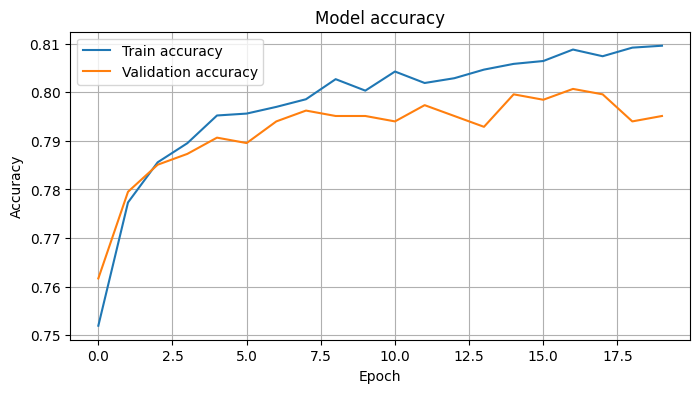

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

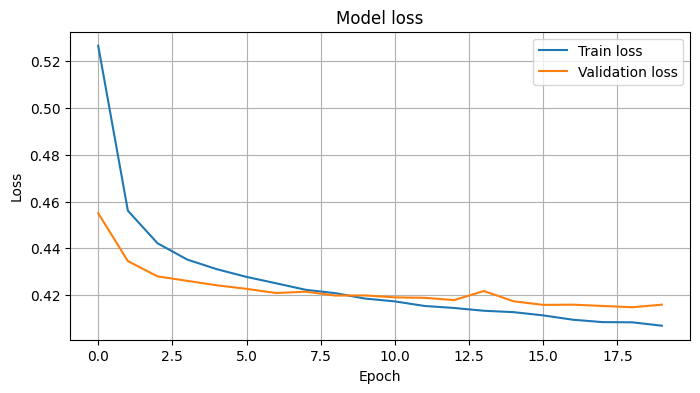

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
predictions = model.predict(X_test)

print(predictions[:5])
print("Передбачені класи:", np.argmax(predictions[:5], axis=1))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[0.5718042  0.42819586]
 [0.835946   0.16405399]
 [0.9916884  0.00831153]
 [0.34082615 0.6591738 ]
 [0.99885666 0.00114334]]
Передбачені класи: [0 0 0 1 0]
